In [1]:
import max2769_uart
import numpy as np
import matplotlib.pyplot as plt
import sdr_tx
import time
from gps import gps

In [2]:
sdr = sdr_tx.Sdr()
sdr.configure(fs=4.092e6, gain=-40)

max = max2769_uart.Max2769Uart("/dev/serial/by-id/usb-Digilent_Digilent_USB_Device_210183B167BB-if01-port0", baud=3125000)

In [10]:
def gen_clk_reg(l: int, m: int, fclk, adcclk, serclk, mode):
    val = (
        ((l & 0xFFF) << 16)
        | ((m & 0xFFF) << 4)
        | ((fclk & 0x1) << 3)
        | ((adcclk & 0x1) << 2)
        | ((serclk & 0x1) << 1)
        | (mode & 0x1)
    )

    return val

In [ ]:
# Configure streaming interface

# Working values

max.write_register(0x00, 0xA295011)
max.write_register(0x01, 0x8550488)
max.write_register(0x02, 0xEAFEBF2)
max.write_register(0x03, 0x9EC0008)
max.write_register(0x04, 0x0C08080)
max.write_register(0x05, 0x0000070)
max.write_register(0x06, 0x8000000)
max.write_register(0x07, 0x4004002)
max.write_register(0x02, 0xEAFEBF2)
max.write_register(0x02, 0xEAFEDF2)

In [45]:
# # Configure streaming interface

# max.write_register(0x00, 0xA295011)
# max.write_register(0x01, 0x8550488)
# max.write_register(0x02, 0xEAFEBF2)
# max.write_register(0x03, 0x9EC0008)
# max.write_register(0x04, 0x0C08080)
# max.write_register(0x05, 0x0000070)
# max.write_register(0x06, 0x8000000)
# # max.write_register(0x07, 0x800800A) # TODO: figure out clocking for ADC and SER
# max.write_register(0x07, gen_clk_reg(l=1024, m=1024, fclk=1, adcclk=0, serclk=0, mode=1))
# max.write_register(0x02, 0xEAFEBF2)
# max.write_register(0x02, 0xEAFEDF2)

max.write_register(0x00, 0xA295001)
max.write_register(0x01, 0x8550488)
max.write_register(0x03, 0x9EC0008)
max.write_register(0x04, 0x0C08080)
max.write_register(0x05, 0x0000070)
max.write_register(0x06, 0x8000000)
max.write_register(0x07, gen_clk_reg(l=1024, m=1024, fclk=1, adcclk=0, serclk=0, mode=1))
max.write_register(0x02, 0xEAFEBF2)
max.write_register(0x02, 0xEAFEDF2)

In [142]:
# 2.046 MHz IF
max.write_register(0x00, 0xA29500A)
max.write_register(0x01, 0x8550488)
max.write_register(0x02, 0xEAFFBF2)
max.write_register(0x03, 0x98C0008)
max.write_register(0x04, 0x0C04080)
max.write_register(0x05, 0x8000070)
max.write_register(0x06, 0x8000000)
# max.write_register(0x07, gen_clk_reg(1024, 1024, 1, 0, 0, 1))
max.write_register(0x07, gen_clk_reg(1024, 1024, 1, 0, 0, 1))

max.write_register(0x02, 0xEAFFBF2)
max.write_register(0x02, 0xEAFFDF2)

In [46]:
sdr.tx_prn(1)
# configs = sdr.tx_gps(1)
# print(configs)

# for i in range(20):
    # max.write_register(0x00, 0xA295003 | (i << 5))
    # time.sleep(0.5)
    # max.write_register(0x00, 0xA295003 | (i << 5))

    # print(f"FCEN={i}")
    # time.sleep(1)

for _ in range(2):
    samples = max.get_samples(14)
    print(gps.acquisition(samples, 4.092e6, 1e6, 1e3, threshold=0))

[[1, -44956.0546875, 1191, 4.489331607063502], [2, 19980.46875, 1620, 4.325562395577587], [3, -91910.15625, 183, 4.22956246473166], [4, 73927.734375, 368, 4.932046253017794], [5, 105896.484375, 1475, 4.373265739398449], [6, -19980.46875, 2231, 4.17729607959556], [7, -176827.1484375, 2872, 4.562062211239298], [8, -101900.390625, 1312, 4.465656726473348], [9, 27972.65625, 2973, 4.086488111580917], [10, -207796.875, 1020, 4.798818795819863], [11, 56944.3359375, 1116, 4.798599058658241], [12, 267738.28125, 100, 4.819386734397371], [13, -119882.8125, 1568, 4.506723920578493], [14, 75925.78125, 1320, 4.784809000888683], [15, 116885.7421875, 2080, 4.612184764519386], [16, -92909.1796875, 2988, 4.485353591463713], [17, -173830.078125, 2976, 4.477692175857728], [18, -80920.8984375, 3468, 4.572032931610393], [19, -62938.4765625, 316, 4.354778315807617], [20, -20979.4921875, 3612, 4.118542734477764], [21, 119882.8125, 4020, 4.08121801117529], [22, -45955.078125, 1052, 4.513059314522582], [23, 194

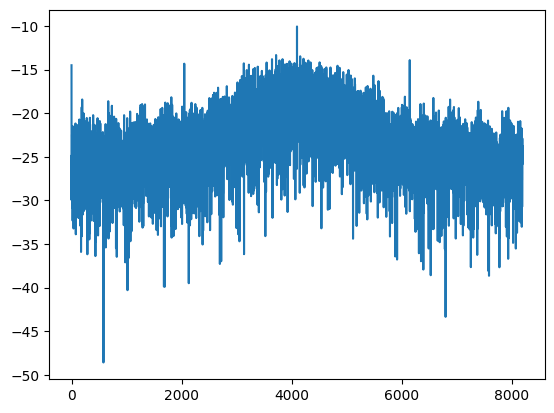

In [43]:
x = max.get_samples(13)
X = np.fft.fftshift(np.fft.fft(x)) / len(x)
X = 10*np.log10(np.abs(X))

plt.plot(X)

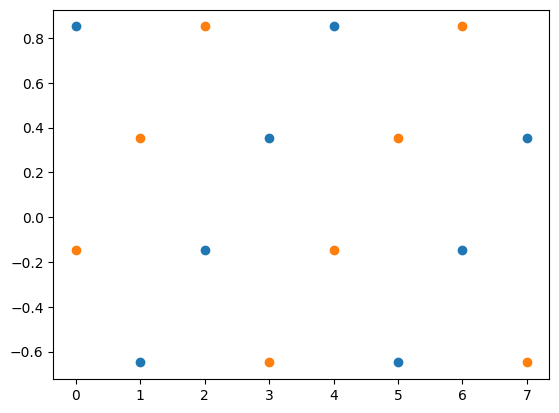

In [12]:
x = max.get_samples(3)
t = np.arange(len(x))

plt.scatter(t, x.real)
plt.scatter(t, x.imag)